In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tracklab import ExperimentReader

from icl import (RunData, logit_table, measure_variables, ansatz_logits,
                 cluster_cross_entropy, logit_blocks, QueryTable)

# Save figure as svg
# path = Path('../../presentation/public/fig/')
path = Path('./')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)

# Plot Configs

In [5]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Code

## Quick verification new order parameters and reduced backend

In [123]:
experiment_name = 'sanity_check'
base_dir = "../data/"
n_artifacts_plot = 7
reader = ExperimentReader(experiment_name, base_dir=base_dir)
table = reader.runs_table(results=True)

run_id = reader.list_runs()[-1]
cfg = reader.load_config(run_id)
logit_positions = cfg['extra_args']['logit_positions']
mu_idx = 2
print(f"Logit positions: {logit_positions}, evaluation index: {mu_idx}")

metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()


logit_list = reader.list_artifacts(run_id,group='logits')
n_artifact_steps = len(logit_list)
time_indexes = np.linspace(0,n_artifact_steps-1,n_artifacts_plot).astype(int)

logits_results = {}
for time_idx in time_indexes:
    file = logit_list.iloc[time_idx]['file']
    time_step = logit_list.iloc[time_idx]['step']
    logits_data = reader.load_artifact(run_id, file,group='logits')
    raw_lists = {}
    vmin , vmax = np.inf, -np.inf
    for key in ['on','off']:
        raw_lists[key] = logits_data[key][mu_idx].flatten()
        print(f'{key}, time step: {time_step}, len: {len(raw_lists[key])}')
        vmin = min(vmin, np.min(logits_data[key][mu_idx]))
        vmax = max(vmax, np.max(logits_data[key][mu_idx]))

    logits_results[time_step] = {}
    for key in ['on','off']:
        hist, bin_edges = np.histogram(raw_lists[key], bins=80, range=(vmin,vmax), density=True)
        logits_results[time_step][key] = hist
    logits_results[time_step]['edges'] = bin_edges

Logit positions: [0.5, 0.75, 1.0], evaluation index: 2
on, time step: 0, len: 2662
off, time step: 0, len: 338074
on, time step: 526, len: 2662
off, time step: 526, len: 338074
on, time step: 1579, len: 2662
off, time step: 1579, len: 338074
on, time step: 2632, len: 2662
off, time step: 2632, len: 338074
on, time step: 3158, len: 2662
off, time step: 3158, len: 338074
on, time step: 4211, len: 2662
off, time step: 4211, len: 338074
on, time step: 5263, len: 2662
off, time step: 5263, len: 338074


In [88]:
reader.load_artifact(run_id, file,group='logits')['off'][-1].shape

(926, 127)

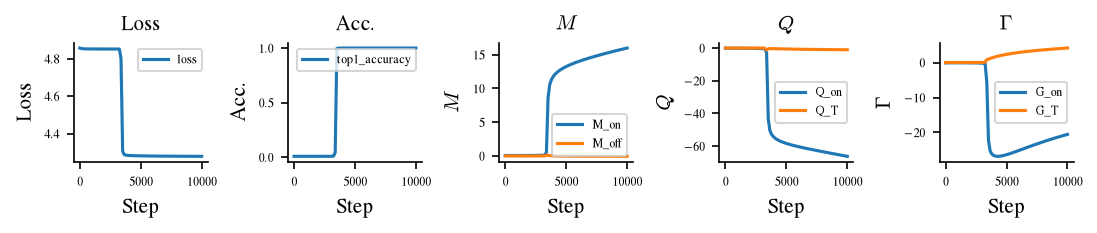

In [119]:
vars_to_plot = {
    'Loss': ['loss'],
    'Acc.': ['top1_accuracy'],
    r'$M$': ['M_on','M_off'],
    r'$Q$': ['Q_on','Q_T'],
    r'$\Gamma$': ['G_on','G_T']
}

fig , axes = create_fig(ncols=len(vars_to_plot),size='double',h=0.2)

for i, (var_name, var_cols) in enumerate(vars_to_plot.items()):
    ax = axes[i] if len(vars_to_plot) > 1 else axes
    for col in var_cols:
        ax.plot(metrics['step'], metrics[col], label=col)
    ax.set_title(var_name)
    ax.set_xlabel('Step')
    ax.set_ylabel(var_name)
    ax.legend()

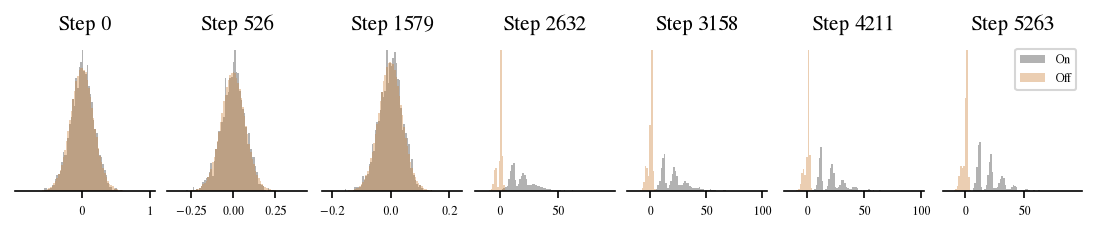

In [124]:
fig , axes = create_fig(ncols=n_artifacts_plot,size='double',h=0.2,sharex=False)

for i , (time_step, logits_data) in enumerate(logits_results.items()):
    ax = axes[i] 
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    on , off , edges = logits_data['on'], logits_data['off'], logits_data['edges']
    ax.bar(edges[:-1], on, width=np.diff(edges), alpha=0.6, label='On', color='gray', align='edge')
    ax.bar(edges[:-1], off, width=np.diff(edges), alpha=0.4, label='Off', color='peru', align='edge')
    ax.set_title(f'Step {time_step}')
    # ax.set_yscale('log')
ax.legend()

## Test of new features

### small explanation

In [ ]:
# 1. What a "row" is

# Every analysis here is about one situation: a query position μ in one sequence where the current token is a trigger. That is one row. The row stores everything about that situation:
# - which sequence it comes from (seq);
# - the position (mu);
# - how many times the trigger appeared before (ell);
# - the V logits the model outputs there (logits).

# A batch of 8192 sequences of length L = 256 has about 8192 × 256 / 6 ≈ 350 000 such rows.

# 2. Rows: a small table

# Rows is a Python dict used as a table. Each key is a column, and every tensor column has the same length n:

# A = logit_table(model, batch)

# A["logits"]  shape (n, V)   the V logits of each row, reordered (see section 4)
# A["mu"]      shape (n,)     query position, counted from 1 like the paper
# A["ell"]     shape (n,)     earlier occurrences of the query trigger
# A["seq"]     shape (n,)     index of the sequence in the batch
# A["K"]       int            metadata, not a column
# A.n                         the number of rows

# Row i is A["logits"][i], A["mu"][i], A["ell"][i], A["seq"][i]. If it helps, think of a pandas DataFrame whose logits cell holds a vector of length V. I didn't use pandas because the columns have to stay torch tensors (for autograd in the loss phase) and logits is 2-D.

# 3. logit_table(model, batch, mus=None): building the table

# model = run.model(step)               # the trained model at that step
# batch = run.batch(8192, seed=0)       # 8192 fresh sequences
# A = logit_table(model, batch)         # every trigger query, at every mu
# A = logit_table(model, batch, mus=256)          # only queries at mu = 256
# A = logit_table(model, batch, mus=[128, 256])   # only at those two positions

# It does four things:
# 1. Runs the model on the sequences.
# 2. Keeps only the positions where the input token is a trigger, at the μ you asked for (all of them by default).
# 3. Computes ℓ for each of those positions.
# 4. Reorders each logit vector into the canonical layout.

# 4. The canonical layout

# The raw logit vector is ordered by token id. The token that matters (the target φ(a)) is at a different index in every row, because φ is random per sequence. logit_table reorders each row so that the columns mean the same thing in every row:

# columns:  [ 0 ... K-1 | K ... 2K-2         | 2K-1 ... V-2   | V-1    ]
# meaning:  [ triggers  | outputs of the     | all the other  | target ]
#           [           | other K-1 triggers | V-2K tokens    | phi(a) ]

# So A["logits"][:, -1] is the on-target logit of every row, and A["logits"][:, :K] are the K trigger logits. You don't have to remember the indices; blocks gives the slices:

# bl = blocks(K, V)
# A["logits"][:, bl["on"]]     # (n, 1)      target
# A["logits"][:, bl["trig"]]   # (n, K)      triggers (equal to each other in the ansatz)
# A["logits"][:, bl["out"]]    # (n, K-1)    outputs of the other triggers
# A["logits"][:, bl["rest"]]   # (n, V-2K)   the remaining tokens

# 5. Picking clusters: select and groups

# select filters rows and returns a smaller Rows with the same columns:

# c = A.select(mu=256, ell=2)            # the ell = 2 mode at mu = 256
# c.n                                    # how many rows fell in it
# c["logits"][:, -1]                     # their on-target logits -> histogram
# A.select(mu=256, ell=[1, 2, 3])        # a list means "any of these"

# groups loops over every (μ, ℓ) combination present:

# for (mu, ell), g in A.groups("mu", "ell"):
#     plt.hist(g["logits"][:, -1], label=f"mu={mu}, ell={ell}")

# 6. The ansatz version of the same rows: measure_variables and ansatz_logits

# The same row structure is used for the ansatz:

# v = measure_variables(batch, mus=256)                   # Rows with "N","F","R","W","P","U","Wb","Pb", "mu","ell"
# B = ansatz_logits(v, op, cfg.beta, cfg.seq_len)         # (n, V), same canonical layout

# measure_variables on the same batch and mus produces the same rows in the same order as logit_table. So row i of B is the ansatz prediction for row i of A["logits"], and the two can be compared element by element:

# diff = A["logits"] - B                                  # the background, row by row

# ansatz_logits returns a plain tensor. To filter it by cluster in the same way, put it in a Rows:

# Bt = Rows({"logits": B, "mu": v["mu"], "ell": v["ell"], "K": K})
# Bt.select(mu=256, ell=2)

# 7. cluster_cross_entropy: the loss per cluster

# cl = cluster_cross_entropy(A)
# cl["mu"], cl["ell"]     # one entry per (mu, ell) cluster
# cl["n"]                 # number of rows in that cluster
# cl["ce"]                # mean cross-entropy there: logsumexp(logits) - logits[:, -1]

# Since the target is always the last column, this is the model's loss at each cluster. Phase 4 will produce the same table from the effective model, so you can compare the two directly.

# 8. Saving and loading

# d = A.numpy()             # a plain dict of numpy arrays, e.g. for pickle
# A = Rows.from_numpy(d)    # back to torch
# Rows.cat([A1, A2])        # stack two tables, e.g. from two batches

# The training probe saves logit_table(model, test_batch, mus=...) like this at every artifact step, and run.logit_table(step) loads it back as a Rows.

# A minimal full example

# from icl import RunData, logit_table, blocks

# run = RunData("my_exp", "run_001", base_dir="../data")
# K, V = run.config.data_args.K, run.config.model_args.vocab_size
# A = logit_table(run.model("last"), run.batch(8192, seed=0), mus=run.config.model_args.seq_len)

# for (mu, ell), g in A.groups("mu", "ell"):
#     on = g["logits"][:, blocks(K, V)["on"]].squeeze(1)
#     print(mu, ell, g.n, on.mean().item())

# This prints, for the last position, how many queries fall in each ℓ mode and the mean on-target logit of that mode.

# If any part is still unclear, tell me which one and I'll go through it with a real run's output.

# ✻ Brewed for 35s · done 1:24 PM

# ❯ I want to do two things:
#   1) Previously you mentioned something true that is that I was evaluating only in positions where ind_possible=True which is excluding the ell=0 cases and so now I will like to fix that to make sure I include also that case, then tell me in which parts of the code this issue was affecting.
#   2) I want you to refactor the code you just wrote renaming variables whenever possible to make it more understandable. If it is not explicitly clear do not use single or few letters like v, A, b, ce, etc. Also use a better name for the 'Rows' class because it is not clear and is confusing at first. Make sure you maintain this design choice specially for the codebase but also for the examples you give for me to try.

# I'll start with the ind_possible question by finding every place that filters the test batch or restricts to induction-possible positions.

#   Ran 1 shell command

# The filtering affects the logged loss, the new TriggerLogitTable probe, and the ℓ≥1 metrics (which are unaffected by design). I'll apply the fix in batch.py 
# A minimal full example

# from icl import RunData, logit_table, blocks

# run = RunData("my_exp", "run_001", base_dir="../data")
# K, V = run.config.data_args.K, run.config.model_args.vocab_size
# A = logit_table(run.model("last"), run.batch(8192, seed=0), mus=run.config.model_args.seq_len)

# for (mu, ell), g in A.groups("mu", "ell"):
#     on = g["logits"][:, blocks(K, V)["on"]].squeeze(1)
#     print(mu, ell, g.n, on.mean().item())

# This prints, for the last position, how many queries fall in each ℓ mode and the mean on-target logit of that mode.
# ● Write(src/icl
# from

In [2]:
experiment_name = 'ansatz_test'
base_dir = "../data/"

reader = ExperimentReader(experiment_name, base_dir=base_dir)
run_id = reader.list_runs()[-1]

run = RunData(experiment_name, run_id, base_dir=base_dir)
cfg = run.config.model_args
L = cfg.seq_len
V = cfg.vocab_size
K = run.config.data_args.K
beta = cfg.beta

steps = run.steps(group='matrices')
step = steps[-1] # 'last'

model, batch = run.model(step), run.batch(8192)        # fresh, unfiltered batch


model_logits = logit_table(model, batch, mus=L)       # QueryTable, every trigger query, ell >= 0
blocks = logit_blocks(K, V)

###
# order_params = run.order_params("last")
# variables = measure_variables(batch, mus=[128, 256])            # same rows, same order
# ansatz = ansatz_logits(variables, order_params, model_args.beta, model_args.seq_len)
# background = model_logits["logits"] - ansatz

# blocks = logit_blocks(K, model_args.vocab_size)
# for (mu, ell), cluster in model_logits.groups("mu", "ell"):
#     target_logits = cluster["logits"][:, blocks["target"]].squeeze(1)
#     print(mu, ell, cluster.num_rows, target_logits.mean().item())

# per_cluster = cluster_cross_entropy(model_logits)               # "mu", "ell", "count", "cross_entropy"
# ansatz_table = QueryTable({"logits": ansatz, "mu": variables["mu"], "ell": variables["ell"], "K": K})
# ansatz_table.select(mu=256, ell=0)                              # the ell = 0 mode, now always present

In [3]:
blocks.keys()

dict_keys(['triggers', 'other_outputs', 'rest', 'target', 'non_target'])

(-20.0, 70.0)

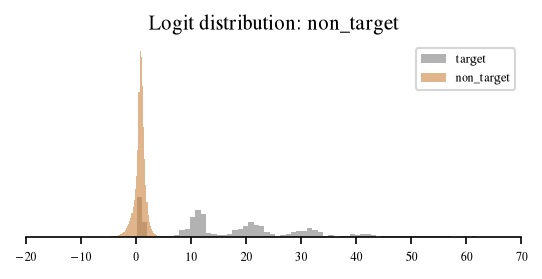

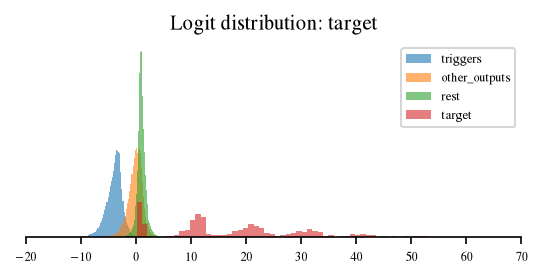

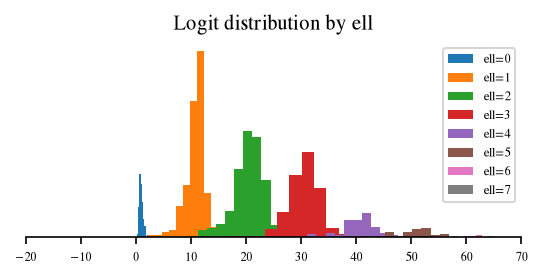

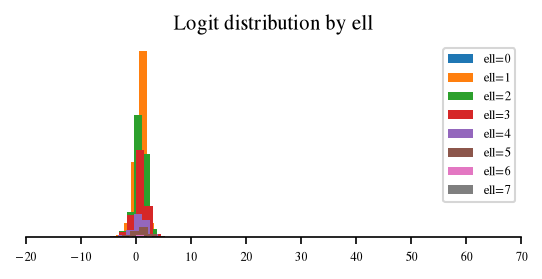

In [6]:
fig , axes = create_fig()

ax = axes
logits = model_logits["logits"]

for blk in ['target','non_target']:
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.hist(logits[:, blocks[blk]].flatten().numpy(), bins=80, alpha=0.6, label=blk, color='gray' if blk=='target' else 'peru',density=True)
    ax.set_title(f'Logit distribution: {blk}')
ax.legend()

ax.set_xlim(-20,70)

fig , axes = create_fig()

ax = axes
logits = model_logits["logits"]

for blk in ['triggers', 'other_outputs', 'rest', 'target']:
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.hist(logits[:, blocks[blk]].flatten().numpy(), bins=80, alpha=0.6, label=blk,density=True)
    ax.set_title(f'Logit distribution: {blk}')
ax.legend()

ax.set_xlim(-20,70)

fig , axes = create_fig()

ax = axes
ax.spines['left'].set_visible(False)
ax.set_yticks([])

for (ell,), group in model_logits.groups("ell"):
    logits = group['logits']

    ax.hist(logits[:, blocks['target']].flatten().numpy(),label=f'ell={ell}')
    ax.set_title(f'Logit distribution by ell')
ax.legend()

ax.set_xlim(-20,70)

fig , axes = create_fig()

ax = axes
ax.spines['left'].set_visible(False)
ax.set_yticks([])

for (ell,), group in model_logits.groups("ell"):
    logits = group['logits']

    ax.hist(logits[:, blocks['non_target']].flatten().numpy(),label=f'ell={ell}')
    ax.set_title(f'Logit distribution by ell')
ax.legend()

ax.set_xlim(-20,70)



In [7]:

blocks.keys()

# v = measure_variables(batch, mus=256)                   # Rows with "N","F","R","W","P","U","Wb","Pb", "mu","ell"
# B = ansatz_logits(v, op, cfg.beta, cfg.seq_len)         # (n, V), same canonical layout

# measure_variables on the same batch and mus produces the same rows in the same order as logit_table. So row i of B is the ansatz prediction for row i of A["logits"], and the two can be compared element by element:

# diff = A["logits"] - B                                  # the background, row by row

# ansatz_logits returns a plain tensor. To filter it by cluster in the same way, put it in a Rows:

# Bt = Rows({"logits": B, "mu": v["mu"], "ell": v["ell"], "K": K})
# Bt.select(mu=256, ell=2)


dict_keys(['triggers', 'other_outputs', 'rest', 'target', 'non_target'])

In [8]:

###
order_params = run.order_params(step)
variables = measure_variables(batch, mus=L)            # same rows, same order
ansatz = ansatz_logits(variables, order_params, beta,L)

sampled_logits = QueryTable({"logits": ansatz, "mu": variables["mu"], "ell": variables["ell"], "K": K})




In [9]:
order_params

{'M_on': -14.35824203491211,
 'M_off': 0.07789964228868484,
 'Q_on': -44.528690338134766,
 'Q_T': -0.8628231883049011,
 'G_on': 16.43873405456543,
 'G_T': -2.655546188354492}

(-20.0, 70.0)

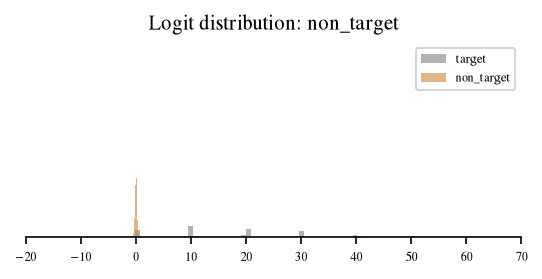

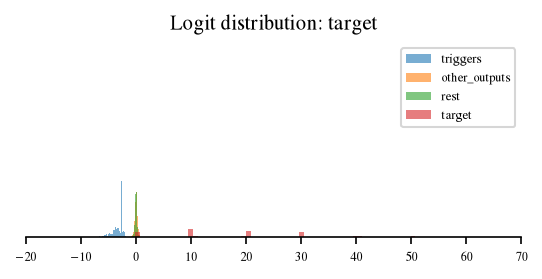

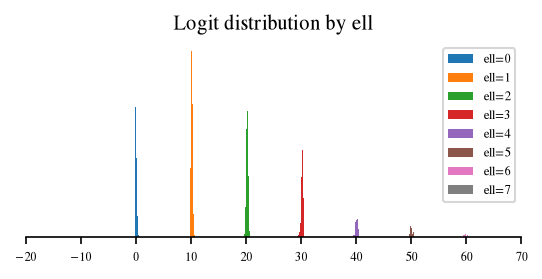

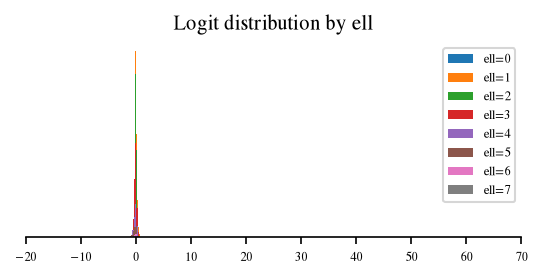

In [11]:
fig , axes = create_fig()

ax = axes
logits = sampled_logits["logits"]

for blk in ['target','non_target']:
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.hist(logits[:, blocks[blk]].flatten().numpy(), bins=80, alpha=0.6, label=blk, color='gray' if blk=='target' else 'peru',density=True)
    ax.set_title(f'Logit distribution: {blk}')
ax.legend()

ax.set_xlim(-20,70)

fig , axes = create_fig()

ax = axes
logits = sampled_logits["logits"]

for blk in ['triggers', 'other_outputs', 'rest', 'target']:
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.hist(logits[:, blocks[blk]].flatten().numpy(), bins=80, alpha=0.6, label=blk,density=True)
    ax.set_title(f'Logit distribution: {blk}')
ax.legend()

ax.set_xlim(-20,70)

fig , axes = create_fig()

ax = axes
ax.spines['left'].set_visible(False)
ax.set_yticks([])

for (ell,), group in sampled_logits.groups("ell"):
    logits = group['logits']

    ax.hist(logits[:, blocks['target']].flatten().numpy(),label=f'ell={ell}')
    ax.set_title(f'Logit distribution by ell')
ax.legend()

ax.set_xlim(-20,70)

fig , axes = create_fig()

ax = axes
ax.spines['left'].set_visible(False)
ax.set_yticks([])

for (ell,), group in sampled_logits.groups("ell"):
    logits = group['logits']

    ax.hist(logits[:, blocks['non_target']].flatten().numpy(),label=f'ell={ell}')
    ax.set_title(f'Logit distribution by ell')
ax.legend()

ax.set_xlim(-20,70)

